In [1]:
import numpy as np
import pandas as pd
import pathlib
from keras import layers
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
import sklearn
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.animation import FuncAnimation
from sklearn.linear_model import LinearRegression
import cv2
from IPython.display import HTML

In [2]:
ds_path = pathlib.Path("points")

In [3]:
path = list((ds_path / "0").glob("*.npy"))[0]
print(path)

points = np.load(path)

points\0\100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4_3dkeypoints.npy


# Смотрим скелет

In [4]:
SKELETON = """
0-1
1-2
2-3
3-20
4-5
5-6
6-7
7-20
8-9
9-10
10-11
11-20
12-13
13-14
14-15
15-20
16-17
17-18
17-19
19-20
"""
SKELETON = SKELETON.strip().split("\n")
SKELETON = [tuple(map(int, i.split("-"))) for i in SKELETON]

In [5]:
def show_skeleton(frames):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter([], [], [], c='b', s=50)
    skeleton_lines = [ax.plot([], [], [], 'r-', linewidth=2)[0] for _ in SKELETON]
    
    all_coords = frames.reshape(-1, 3)
    ax.set_xlim(np.min(all_coords[:, 0]), np.max(all_coords[:, 0]))
    ax.set_ylim(np.min(all_coords[:, 1]), np.max(all_coords[:, 1]))
    ax.set_zlim(np.min(all_coords[:, 2]), np.max(all_coords[:, 2]))
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    
    def update_skeleton(frame):
        frame_data = frames[frame]
        x, y, z = frame_data[:, 0], frame_data[:, 1], frame_data[:, 2]
        
        scatter._offsets3d = (x, y, z)
        
        # Update skeleton lines
        for i, (start_idx, end_idx) in enumerate(SKELETON):
            skeleton_lines[i].set_data(
                [x[start_idx], x[end_idx]],
                [y[start_idx], y[end_idx]]
            )
            skeleton_lines[i].set_3d_properties(
                [z[start_idx], z[end_idx]]
            )
        
        ax.set_title(f'Frame: {frame}')
        return [scatter] + skeleton_lines
    
    ani = FuncAnimation(fig, update_skeleton, frames=len(frames), interval=50, blit=False)
    return HTML(ani.to_jshtml())

# Загружаем датасет

In [4]:
ds_path = pathlib.Path("points")
classes = ["0", "1", "2", "3"]

filenames = []
X_orig = []
X = []
y = []

for cls in classes:
    cls_dir = ds_path / cls
    for file_path in cls_dir.glob("*.npy"):
        pts = np.load(file_path)
        X_orig.append(pts)
        filenames.append(file_path.stem)
        # print(pts)
        pts = pts.reshape(-1, 21 * 3)  # Решейпим 21 3д точки в один вектор чисел на 63 элемента
        X.append(pts)
        y.append(int(cls))
y = np.array(y)

# Добавляем паддинг входным данным, чтобы они были одинакового размера
X = tf.keras.utils.pad_sequences(X, padding="post")

# Нормализуем
X = X.astype(float)
X /= X.max()


# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
print("Train:", len(X_train))
print("Test:", len(X_test))

print("input_shape =", X.shape[1:])

Train: 445
Test: 50
input_shape = (629, 63)


# RNN

In [7]:
# Делаем датасет из tf
def augment(x):  # небольшая аугментация со случайным смещением точек
    mul = tf.random.uniform(shape=x.shape, minval=0.99, maxval=1.01, dtype=tf.float64)
    return x * mul

train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.map(lambda x, y: (augment(x), y))
train = train.shuffle(1000)
train = train.batch(8)

test = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test = test.batch(8)

In [14]:
model = keras.Sequential([
    layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),
    layers.LSTM(128, input_shape=X.shape[1:], activation='tanh', return_sequences=True),  # Возвращает (629, 128)
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    layers.LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    # BatchNormalization(),
    # Dropout(0.1),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(4, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer="Adam",
    metrics=['accuracy'],
)

hist = model.fit(
    train,
    epochs=50,
    validation_data=test,
)

Epoch 1/50
55/55 [==============================] - 21s 329ms/step - loss: 1.6244 - accuracy: 0.2938 - val_loss: 1.3612 - val_accuracy: 0.3469
Epoch 2/50
55/55 [==============================] - 16s 281ms/step - loss: 1.3447 - accuracy: 0.3804 - val_loss: 1.3848 - val_accuracy: 0.2449
Epoch 3/50
55/55 [==============================] - 17s 314ms/step - loss: 1.3085 - accuracy: 0.3941 - val_loss: 1.4330 - val_accuracy: 0.1837
Epoch 4/50
55/55 [==============================] - 16s 281ms/step - loss: 1.2590 - accuracy: 0.4169 - val_loss: 1.4197 - val_accuracy: 0.3469
Epoch 5/50
55/55 [==============================] - 18s 322ms/step - loss: 1.1366 - accuracy: 0.4761 - val_loss: 1.3629 - val_accuracy: 0.3673
Epoch 6/50
55/55 [==============================] - 15s 275ms/step - loss: 1.1356 - accuracy: 0.4897 - val_loss: 1.3605 - val_accuracy: 0.3265
Epoch 7/50
55/55 [==============================] - 18s 319ms/step - loss: 1.1661 - accuracy: 0.4943 - val_loss: 1.4205 - val_accuracy: 0.4082

In [25]:
model.save("model.keras")

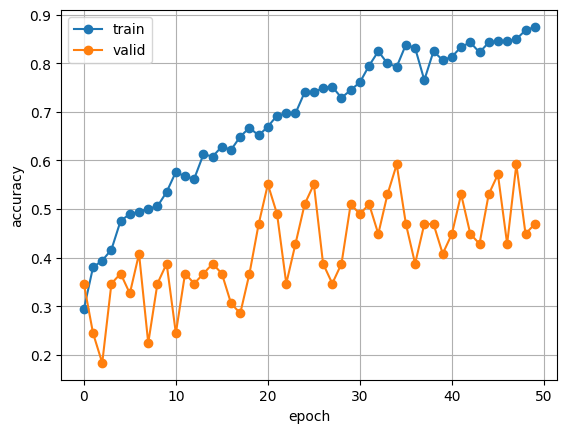

In [22]:
plt.plot(hist.history["accuracy"], marker="o")
plt.plot(hist.history["val_accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid()
plt.legend(["train", "valid"])
plt.show()

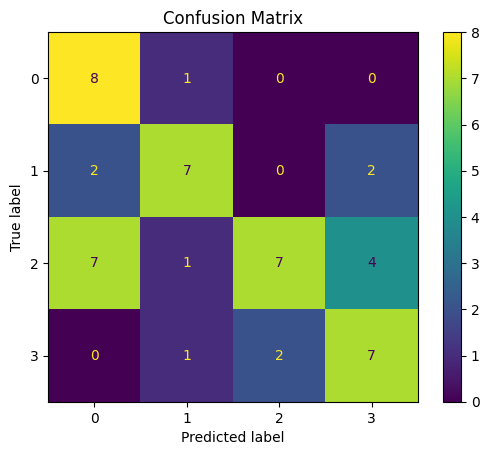

In [62]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
model = keras.models.load_model("model.keras")

y_pred = model(X_test).numpy().argmax(axis=1)
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

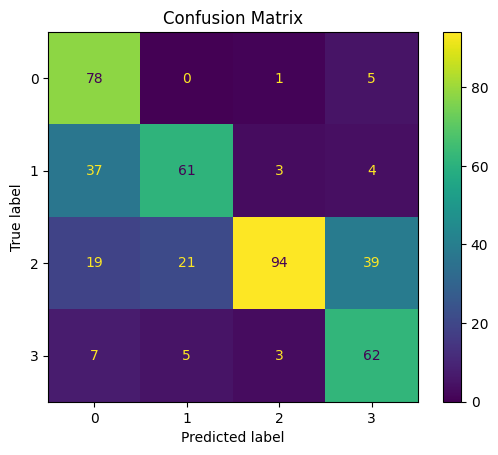

In [61]:
y_pred = model(X_train).numpy().argmax(axis=1)
y_true = y_train
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Определение углов через вектора

In [45]:
def get_frames_std(frames):
    # Находит дисперсию точек в каждом кадре
    # frames: (n * 21 * 3)
    mean_pts = frames.mean(axis=1)
    diff = frames - mean_pts[:, None, :]
    norms = np.linalg.norm(diff, axis=2)
    return norms.mean(axis=1)


def filter_frames(frames):
    # Фильтрует кадры по максимальной дисперсии
    max_std = 50
    return frames[get_frames_std(frames) < max_std]
    

def get_points_norm(points: np.ndarray):
    """Находит нормаль плоскости, проходящей через точки"""
    points -= points.mean(axis=0)
    points /= points.std(axis=0)
    if np.any(np.isnan(points)):
        return np.array((0, 0, 0))
    l = LinearRegression(fit_intercept=False).fit(points[:, [0, 1]], points[:, 2])
    norm = np.array((l.coef_[0], l.coef_[1], -1))
    return norm


def vectors_angle(v1, v2):
    """Угол между векторами"""
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)
    return np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0))
    

def get_angle_range(frames: np.ndarray):
    """
    Находит размах угла поворота в градусах по кадрам с 3д точками
    """
    norms = []
    for frame in frames.copy():
        v1 = frame[20] - frame[0]  # вектор до большого пальца
        v2 = frame[20] - frame[16]  # вектор до мизинца
        norms.append(np.cross(v1, v2))

    angle = []
    n0 = norms[0]
    for n in norms:
        angle.append(vectors_angle(n0, n))
        
    angle = np.array(angle)
    min_angle, max_angle = np.quantile(angle, 0.05), np.quantile(angle, 0.95)
    rotation_range = np.rad2deg(max_angle - min_angle)

    # fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
    # ax[0].plot(angle)
    # ax[0].set_xlabel("Номер кадра")
    # ax[0].set_ylabel("Угол поворота, радианы")
    # ax[1].hist(angle, bins=30, orientation='horizontal')
    # plt.show()
    # print(f"Размах вращения: {rotation_range:.2f} градусов")
    
    return rotation_range

In [46]:
video_angles = []
for i in range(len(filenames)):
    video_angles.append(get_angle_range(X_orig[i]))
video_angles = np.array(video_angles)

/tmp/ipykernel_2826/4005951290.py:30: RuntimeWarning: invalid value encountered in divide
  v2 = v2 / np.linalg.norm(v2)


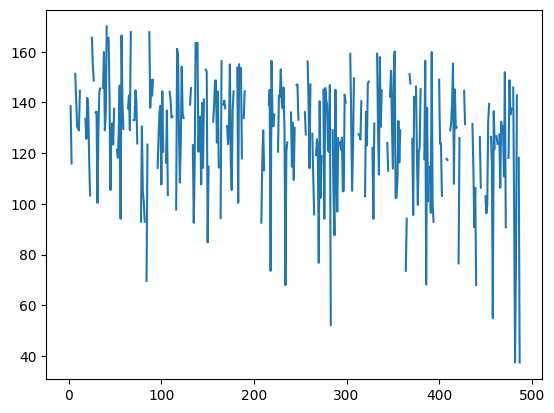

In [44]:
# Предсказания углов для каждого видео
plt.plot(video_angles)

Text(0, 0.5, 'Средний угол')

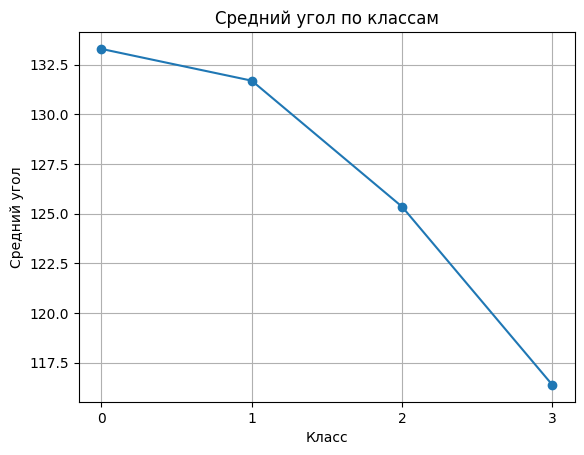

In [58]:
mean_class_angles = []
for c in range(4):
    ang = video_angles[~np.isnan(video_angles) & (y == c)]
    mean_class_angles.append(ang.mean())

plt.title("Средний угол по классам")
plt.plot(["0", "1", "2", "3"], mean_class_angles, marker="o")
plt.grid()
plt.xlabel("Класс")
plt.ylabel("Средний угол")

# Исследование 2

RNN

In [1]:
import numpy as np
import pandas as pd
import pathlib
from keras import layers
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
import sklearn
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.animation import FuncAnimation
from sklearn.linear_model import LinearRegression
import cv2
from IPython.display import HTML

In [2]:
ds_path = pathlib.Path("points")

In [3]:
path = list((ds_path / "0").glob("*.npy"))[0]
print(path)

points = np.load(path)

points\0\100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4_3dkeypoints.npy


Загружаем датасет

In [4]:
ds_path = pathlib.Path("points")
classes = ["0", "1", "2", "3"]

filenames = []
X_orig = []
X = []
y = []

for cls in classes:
    cls_dir = ds_path / cls
    for file_path in cls_dir.glob("*.npy"):
        pts = np.load(file_path)
        X_orig.append(pts)
        filenames.append(file_path.stem)
        # print(pts)
        pts = pts.reshape(-1, 21 * 3)  # Решейпим 21 3д точки в один вектор чисел на 63 элемента
        X.append(pts)
        y.append(int(cls))
y = np.array(y)

# Добавляем паддинг входным данным, чтобы они были одинакового размера
X = tf.keras.utils.pad_sequences(X, padding="post")

# Нормализуем
X = X.astype(float)
X /= X.max()


# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
print("Train:", len(X_train))
print("Test:", len(X_test))

print("input_shape =", X.shape[1:])

Train: 445
Test: 50
input_shape = (629, 63)


In [5]:
# Делаем датасет из tf
def augment(x):  # небольшая аугментация со случайным смещением точек
    mul = tf.random.uniform(shape=x.shape, minval=0.99, maxval=1.01, dtype=tf.float64)
    return x * mul

train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.map(lambda x, y: (augment(x), y))
train = train.shuffle(1000)
train = train.batch(8)

test = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test = test.batch(8)

In [ ]:
# model = keras.Sequential([
#     layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),
#     layers.LSTM(128, input_shape=X.shape[1:], activation='tanh', return_sequences=True),  # Возвращает (629, 128)
#     layers.BatchNormalization(),
#     layers.Dropout(0.1),
    
#     layers.LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
#     layers.BatchNormalization(),
#     layers.Dropout(0.1),

#     # LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
#     # BatchNormalization(),
#     # Dropout(0.1),
    
#     layers.Dense(32, activation='relu'),
#     layers.Dropout(0.1),
#     layers.Dense(4, activation='softmax'),
# ])

# model.compile(
#     loss='sparse_categorical_crossentropy',
#     optimizer="Adam",
#     metrics=['accuracy'],
# )

# hist = model.fit(
#     train,
#     epochs=50,
#     validation_data=test,
# )

Строим и обучаем модель

In [8]:
# from tensorflow import keras
# from tensorflow.keras import layers, regularizers
# from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# model = keras.Sequential([
#     layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),

#     # Bidirectional LSTM для захвата контекста в обе стороны
#     layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     # Последний LSTM без return_sequences
#     layers.LSTM(64, return_sequences=False),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     # Мощные Dense-слои с регуляризацией
#     layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
#     layers.BatchNormalization(),
#     layers.Dropout(0.3),

#     layers.Dense(4, activation='softmax'),
# ])

# model.compile(
#     loss='sparse_categorical_crossentropy',
#     optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#     metrics=['accuracy'],
# )


вариант из 1

In [ ]:
model = keras.Sequential([
    layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),
    layers.LSTM(128, input_shape=X.shape[1:], activation='tanh', return_sequences=True),  # Возвращает (629, 128)
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    layers.LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    # BatchNormalization(),
    # Dropout(0.1),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(4, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer="Adam",
    metrics=['accuracy'],
)

hist = model.fit(
    train,
    epochs=50,
    validation_data=test,
)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

model = keras.Sequential([
    # Маскирование паддингов
    layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),

    # Первый LSTM
    layers.LSTM(128, activation='tanh', return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # Второй LSTM
    layers.LSTM(64, activation='tanh', return_sequences=False),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # Более мощная Dense-часть с регуляризацией и нормализацией
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.1),

    layers.Dense(4, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy'],
)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Сохраняет лучшую модель по val_loss
checkpoint = ModelCheckpoint(
    filepath='models/model_v2.keras',
    monitor='val_loss',    
    save_best_only=True,
    save_weights_only=False,
    verbose=1        
)

# Уменьшает learning rate, если val_loss не улучшается
lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
hist = model.fit(
    train,
    epochs=50,
    validation_data=test,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/50
56/56 [==============================] - ETA: 0s - loss: 1.7105 - accuracy: 0.2742
Epoch 1: val_loss improved from inf to 1.47680, saving model to models\model_v2.keras
56/56 [==============================] - 59s 747ms/step - loss: 1.7105 - accuracy: 0.2742 - val_loss: 1.4768 - val_accuracy: 0.3200 - lr: 0.0010
Epoch 2/50
56/56 [==============================] - ETA: 0s - loss: 1.4558 - accuracy: 0.4045
Epoch 2: val_loss improved from 1.47680 to 1.47523, saving model to models\model_v2.keras
56/56 [==============================] - 38s 655ms/step - loss: 1.4558 - accuracy: 0.4045 - val_loss: 1.4752 - val_accuracy: 0.3000 - lr: 0.0010
Epoch 3/50
56/56 [==============================] - ETA: 0s - loss: 1.4643 - accuracy: 0.3753
Epoch 3: val_loss did not improve from 1.47523
56/56 [==============================] - 39s 664ms/step - loss: 1.4643 - accuracy: 0.3753 - val_loss: 1.5070 - val_accuracy: 0.2800 - lr: 0.0010
Epoch 4/50
56/56 [==============================] - ETA: 0s 

In [ ]:
# model.save("model.keras")

In [ ]:
plt.plot(hist.history["accuracy"], marker="o")
plt.plot(hist.history["val_accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid()
plt.legend(["train", "valid"])
plt.show()

# Проверка

In [5]:
# Проверка
# Делаем датасет из tf
def augment(x):  # небольшая аугментация со случайным смещением точек
    mul = tf.random.uniform(shape=x.shape, minval=0.99, maxval=1.01, dtype=tf.float64)
    return x * mul

train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train = train.map(lambda x, y: (augment(x), y))
train = train.shuffle(1000)
train = train.batch(8)

test = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test = test.batch(8)

In [6]:
# Проверка
model = keras.Sequential([
    layers.Masking(mask_value=0.0, input_shape=X.shape[1:]),
    layers.LSTM(128, input_shape=X.shape[1:], activation='tanh', return_sequences=True),  # Возвращает (629, 128)
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    layers.LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # LSTM(128, activation='tanh', return_sequences=False),  # Возвращает вектор 128
    # BatchNormalization(),
    # Dropout(0.1),
    
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(4, activation='softmax'),
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer="Adam",
    metrics=['accuracy'],
)

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Сохраняет лучшую модель по val_loss
checkpoint = ModelCheckpoint(
    filepath='models/model_v3.keras',
    monitor='val_loss',    
    save_best_only=True,
    save_weights_only=False,
    verbose=1        
)

# Уменьшает learning rate, если val_loss не улучшается
lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.9,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

In [8]:
hist = model.fit(
    train,
    epochs=50,
    validation_data=test,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/50
56/56 [==============================] - ETA: 0s - loss: 1.5849 - accuracy: 0.3191
Epoch 1: val_loss improved from inf to 1.35506, saving model to models\model_v3.keras
56/56 [==============================] - 62s 845ms/step - loss: 1.5849 - accuracy: 0.3191 - val_loss: 1.3551 - val_accuracy: 0.3800 - lr: 0.0010
Epoch 2/50
56/56 [==============================] - ETA: 0s - loss: 1.3827 - accuracy: 0.3910
Epoch 2: val_loss improved from 1.35506 to 1.33489, saving model to models\model_v3.keras
56/56 [==============================] - 41s 713ms/step - loss: 1.3827 - accuracy: 0.3910 - val_loss: 1.3349 - val_accuracy: 0.3800 - lr: 0.0010
Epoch 3/50
56/56 [==============================] - ETA: 0s - loss: 1.3250 - accuracy: 0.3685
Epoch 3: val_loss did not improve from 1.33489
56/56 [==============================] - 45s 778ms/step - loss: 1.3250 - accuracy: 0.3685 - val_loss: 1.3527 - val_accuracy: 0.4000 - lr: 0.0010
Epoch 4/50
56/56 [==============================] - ETA: 0s 

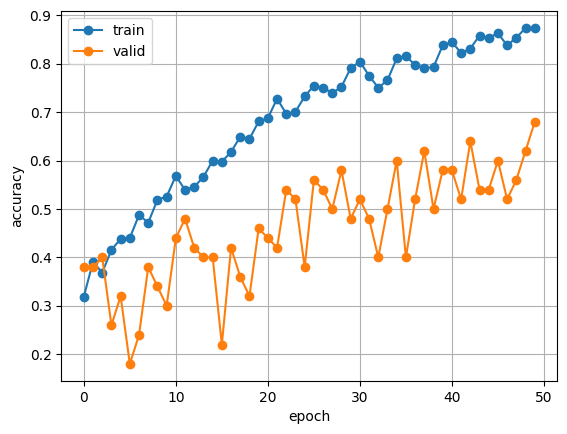

In [9]:
plt.plot(hist.history["accuracy"], marker="o")
plt.plot(hist.history["val_accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid()
plt.legend(["train", "valid"])
plt.show()

немного дообучим модель

In [ ]:
# from tensorflow.keras.models import load_model

# # Загрузка модели
# model = load_model('models/best_model.keras')

# # Изменение learning rate (например, 1e-4)
# keras.backend.set_value(model.optimizer.learning_rate, 1e-4)

# # Дообучение
# model.fit(
#     train,
#     validation_data=test,
#     epochs=5,
#     callbacks=[checkpoint, lr_schedule],  # или другие
# )


In [10]:
keras.backend.set_value(model.optimizer.learning_rate, 1e-4)

In [11]:
hist2 = model.fit(
    train,
    validation_data=test,
    epochs=5,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/5
56/56 [==============================] - ETA: 0s - loss: 0.2944 - accuracy: 0.8809
Epoch 1: val_loss did not improve from 1.11435
56/56 [==============================] - 34s 595ms/step - loss: 0.2944 - accuracy: 0.8809 - val_loss: 1.3256 - val_accuracy: 0.6800 - lr: 1.0000e-04
Epoch 2/5
56/56 [==============================] - ETA: 0s - loss: 0.3177 - accuracy: 0.8607
Epoch 2: val_loss did not improve from 1.11435
56/56 [==============================] - 35s 609ms/step - loss: 0.3177 - accuracy: 0.8607 - val_loss: 1.3486 - val_accuracy: 0.7000 - lr: 1.0000e-04
Epoch 3/5
56/56 [==============================] - ETA: 0s - loss: 0.3047 - accuracy: 0.8652
Epoch 3: val_loss did not improve from 1.11435
56/56 [==============================] - 35s 596ms/step - loss: 0.3047 - accuracy: 0.8652 - val_loss: 1.3838 - val_accuracy: 0.7200 - lr: 1.0000e-04
Epoch 4/5
56/56 [==============================] - ETA: 0s - loss: 0.3214 - accuracy: 0.8719
Epoch 4: val_loss did not improve from 1

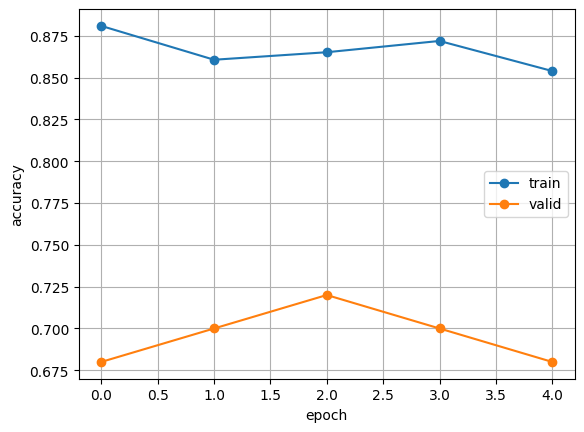

In [12]:
plt.plot(hist2.history["accuracy"], marker="o")
plt.plot(hist2.history["val_accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid()
plt.legend(["train", "valid"])
plt.show()

In [13]:
model.save("models/model_v3.keras")

ещё немного

In [14]:
keras.backend.set_value(model.optimizer.learning_rate, 0.00009)

In [15]:
hist2 = model.fit(
    train,
    validation_data=test,
    epochs=10,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/10
56/56 [==============================] - ETA: 0s - loss: 0.2838 - accuracy: 0.8876
Epoch 1: val_loss did not improve from 1.11435
56/56 [==============================] - 36s 619ms/step - loss: 0.2838 - accuracy: 0.8876 - val_loss: 1.3402 - val_accuracy: 0.7000 - lr: 9.0000e-05
Epoch 2/10
56/56 [==============================] - ETA: 0s - loss: 0.2470 - accuracy: 0.9056
Epoch 2: val_loss did not improve from 1.11435
56/56 [==============================] - 35s 609ms/step - loss: 0.2470 - accuracy: 0.9056 - val_loss: 1.2699 - val_accuracy: 0.7000 - lr: 9.0000e-05
Epoch 3/10
56/56 [==============================] - ETA: 0s - loss: 0.2564 - accuracy: 0.8899
Epoch 3: val_loss did not improve from 1.11435
56/56 [==============================] - 36s 617ms/step - loss: 0.2564 - accuracy: 0.8899 - val_loss: 1.3389 - val_accuracy: 0.6800 - lr: 9.0000e-05
Epoch 4/10
56/56 [==============================] - ETA: 0s - loss: 0.2835 - accuracy: 0.9011
Epoch 4: val_loss did not improve fr

In [16]:
model.save("models/model_v3.keras")

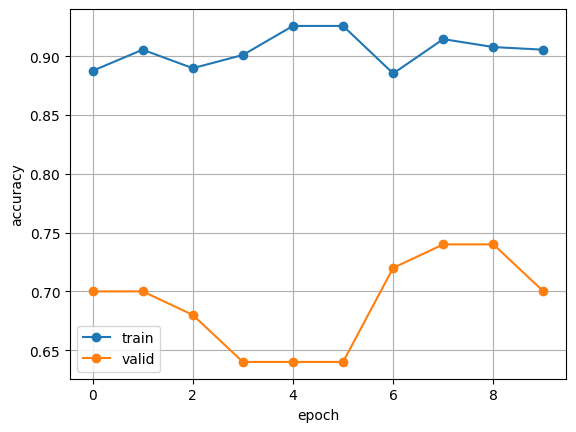

In [17]:
plt.plot(hist2.history["accuracy"], marker="o")
plt.plot(hist2.history["val_accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.grid()
plt.legend(["train", "valid"])
plt.show()

In [18]:
keras.backend.set_value(model.optimizer.learning_rate, 0.00005)

In [19]:
hist3 = model.fit(
    train,
    validation_data=test,
    epochs=15,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/15
56/56 [==============================] - ETA: 0s - loss: 0.2776 - accuracy: 0.8966
Epoch 1: val_loss did not improve from 1.11435
56/56 [==============================] - 36s 622ms/step - loss: 0.2776 - accuracy: 0.8966 - val_loss: 1.3894 - val_accuracy: 0.6400 - lr: 5.0000e-05
Epoch 2/15
56/56 [==============================] - ETA: 0s - loss: 0.2355 - accuracy: 0.9034
Epoch 2: val_loss did not improve from 1.11435
56/56 [==============================] - 37s 633ms/step - loss: 0.2355 - accuracy: 0.9034 - val_loss: 1.2830 - val_accuracy: 0.7200 - lr: 5.0000e-05
Epoch 3/15
56/56 [==============================] - ETA: 0s - loss: 0.2684 - accuracy: 0.8854
Epoch 3: val_loss did not improve from 1.11435
56/56 [==============================] - 36s 625ms/step - loss: 0.2684 - accuracy: 0.8854 - val_loss: 1.4053 - val_accuracy: 0.6800 - lr: 5.0000e-05
Epoch 4/15
56/56 [==============================] - ETA: 0s - loss: 0.2374 - accuracy: 0.8921
Epoch 4: val_loss did not improve fr

In [20]:
keras.backend.set_value(model.optimizer.learning_rate, 0.000001)

In [21]:
hist4 = model.fit(
    train,
    validation_data=test,
    epochs=5,
    callbacks=[checkpoint, lr_schedule],
)

Epoch 1/5
56/56 [==============================] - ETA: 0s - loss: 0.2389 - accuracy: 0.9079
Epoch 1: val_loss did not improve from 1.11435
56/56 [==============================] - 36s 614ms/step - loss: 0.2389 - accuracy: 0.9079 - val_loss: 1.3998 - val_accuracy: 0.7000 - lr: 1.0000e-06
Epoch 2/5
56/56 [==============================] - ETA: 0s - loss: 0.2225 - accuracy: 0.9079
Epoch 2: val_loss did not improve from 1.11435
56/56 [==============================] - 35s 607ms/step - loss: 0.2225 - accuracy: 0.9079 - val_loss: 1.3987 - val_accuracy: 0.7000 - lr: 1.0000e-06
Epoch 3/5
56/56 [==============================] - ETA: 0s - loss: 0.2192 - accuracy: 0.9124
Epoch 3: val_loss did not improve from 1.11435
56/56 [==============================] - 35s 607ms/step - loss: 0.2192 - accuracy: 0.9124 - val_loss: 1.4009 - val_accuracy: 0.7200 - lr: 1.0000e-06
Epoch 4/5
56/56 [==============================] - ETA: 0s - loss: 0.2218 - accuracy: 0.9079
Epoch 4: val_loss did not improve from 1

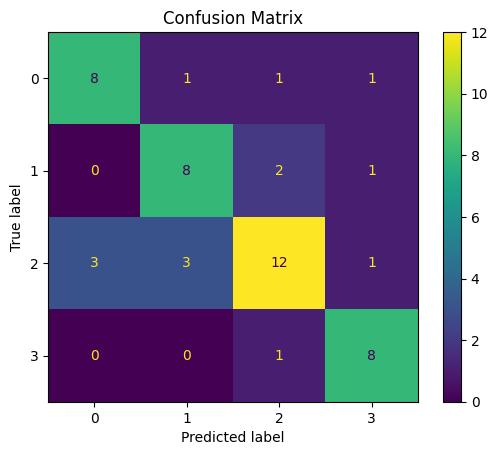

In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# model = keras.models.load_model("model.keras")

y_pred = model(X_test).numpy().argmax(axis=1)
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

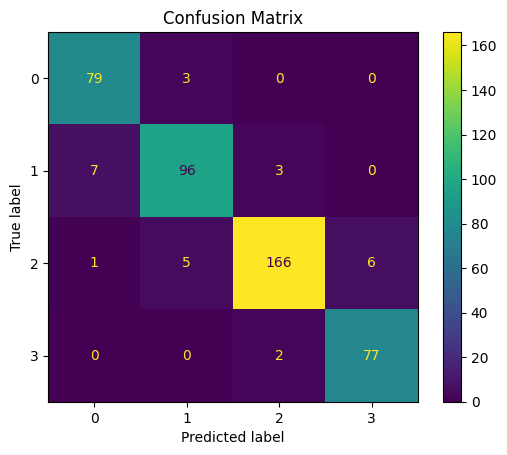

In [23]:
y_pred = model(X_train).numpy().argmax(axis=1)
y_true = y_train
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Определение углов через вектора

In [24]:
def get_frames_std(frames):
    # Находит дисперсию точек в каждом кадре
    # frames: (n * 21 * 3)
    mean_pts = frames.mean(axis=1)
    diff = frames - mean_pts[:, None, :]
    norms = np.linalg.norm(diff, axis=2)
    return norms.mean(axis=1)


def filter_frames(frames):
    # Фильтрует кадры по максимальной дисперсии
    max_std = 50
    return frames[get_frames_std(frames) < max_std]
    

def get_points_norm(points: np.ndarray):
    """Находит нормаль плоскости, проходящей через точки"""
    points -= points.mean(axis=0)
    points /= points.std(axis=0)
    if np.any(np.isnan(points)):
        return np.array((0, 0, 0))
    l = LinearRegression(fit_intercept=False).fit(points[:, [0, 1]], points[:, 2])
    norm = np.array((l.coef_[0], l.coef_[1], -1))
    return norm


def vectors_angle(v1, v2):
    """Угол между векторами"""
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)
    return np.arccos(np.clip(np.dot(v1, v2), -1.0, 1.0))
    

def get_angle_range(frames: np.ndarray):
    """
    Находит размах угла поворота в градусах по кадрам с 3д точками
    """
    norms = []
    for frame in frames.copy():
        v1 = frame[20] - frame[0]  # вектор до большого пальца
        v2 = frame[20] - frame[16]  # вектор до мизинца
        norms.append(np.cross(v1, v2))

    angle = []
    n0 = norms[0]
    for n in norms:
        angle.append(vectors_angle(n0, n))
        
    angle = np.array(angle)
    min_angle, max_angle = np.quantile(angle, 0.05), np.quantile(angle, 0.95)
    rotation_range = np.rad2deg(max_angle - min_angle)

    # fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
    # ax[0].plot(angle)
    # ax[0].set_xlabel("Номер кадра")
    # ax[0].set_ylabel("Угол поворота, радианы")
    # ax[1].hist(angle, bins=30, orientation='horizontal')
    # plt.show()
    # print(f"Размах вращения: {rotation_range:.2f} градусов")
    
    return rotation_range

In [25]:
video_angles = []
for i in range(len(filenames)):
    video_angles.append(get_angle_range(X_orig[i]))
video_angles = np.array(video_angles)

C:\Users\maxim\AppData\Local\Temp\ipykernel_8484\4005951290.py:30: RuntimeWarning: invalid value encountered in divide
  v2 = v2 / np.linalg.norm(v2)


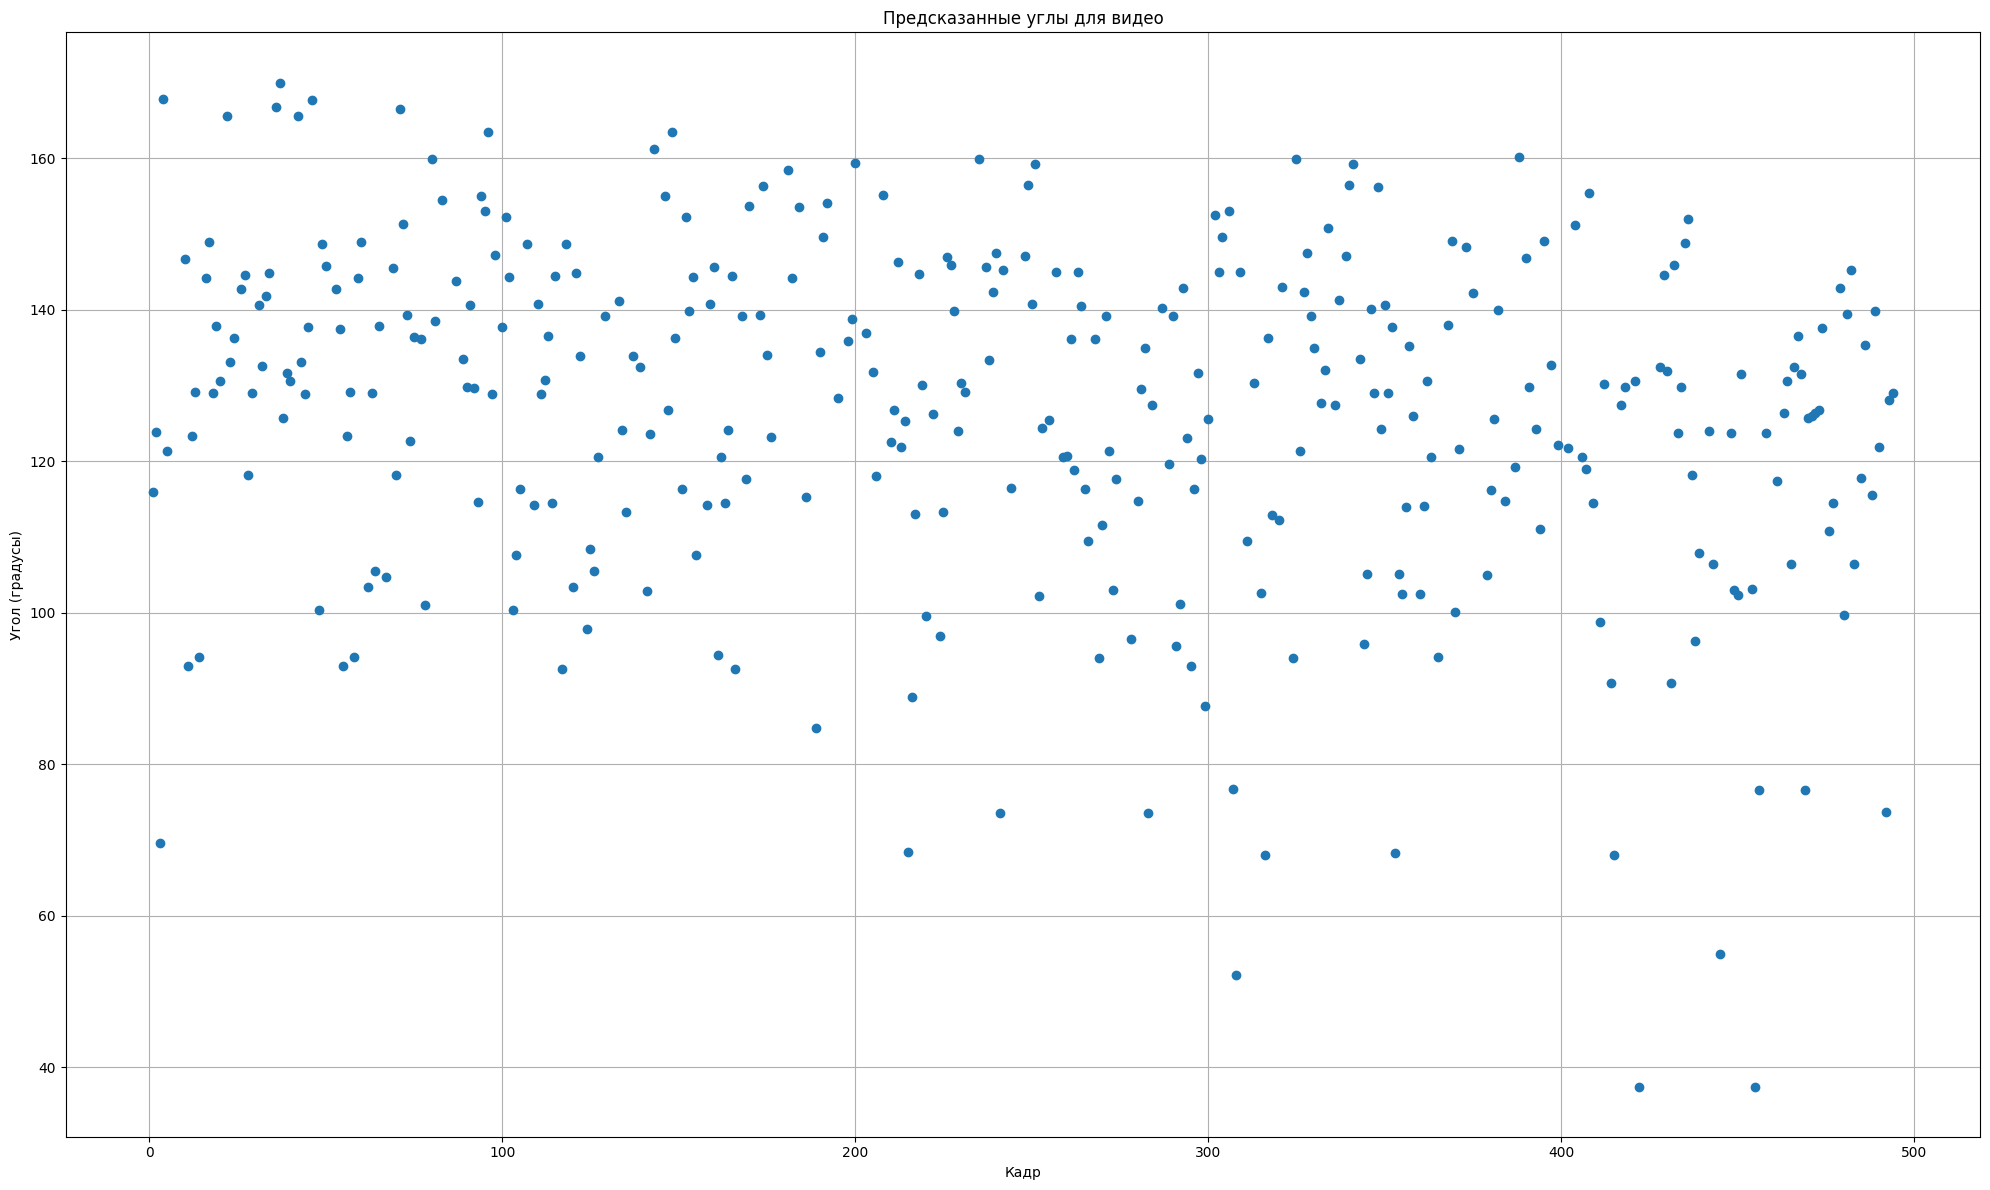

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plt.plot(video_angles, linestyle='None', marker='o')
plt.title("Предсказанные углы для видео")
plt.xlabel("Кадр")
plt.ylabel("Угол (градусы)")
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Средний угол')

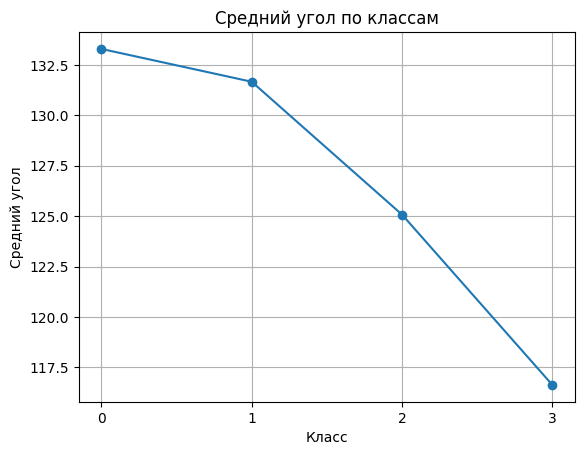

In [27]:
mean_class_angles = []
for c in range(4):
    ang = video_angles[~np.isnan(video_angles) & (y == c)]
    mean_class_angles.append(ang.mean())

plt.title("Средний угол по классам")
plt.plot(["0", "1", "2", "3"], mean_class_angles, marker="o")
plt.grid()
plt.xlabel("Класс")
plt.ylabel("Средний угол")